## **Social Media Engagement Analytics to drive strategy.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_ind

### **SEG 1: Simulating typical social media metrics**

In [15]:
np.random.seed(42)

n = 1000

post_type = np.random.choice(["image", "video", "carousel"], n)
post_time = np.random.choice(["morning", "afternoon", "evening"], n)
followers = np.random.randint(100, 10000, n)

likes = []
comments = []
shares = []

for p in post_type:
    if p == "video":
        likes.append(np.random.randint(500, 1200))
        comments.append(np.random.randint(50, 300))
        shares.append(np.random.randint(20, 150))
    elif p == "image":
        likes.append(np.random.randint(300, 900))
        comments.append(np.random.randint(20, 150))
        shares.append(np.random.randint(10, 80))
    else:
        likes.append(np.random.randint(200, 800))
        comments.append(np.random.randint(10, 120))
        shares.append(np.random.randint(5, 60))

df = pd.DataFrame({
    "post_type": post_type,
    "post_time": post_time,
    "followers": followers,
    "likes": likes,
    "comments": comments,
    "shares": shares
})

df["engagement"] = df["likes"] + df["comments"] + df["shares"]
df["high_engagement"] = (df["engagement"] > df["engagement"].median()).astype(int)

### **SEG 2: Defining scoring metrics for engagement**

In [16]:
df["engagement"] = df["likes"] + df["comments"] + df["shares"]

df["high_engagement"] = (df["engagement"] > df["engagement"].median()).astype(int)

### **SEG 3: Basic EDA to visualize the trends**

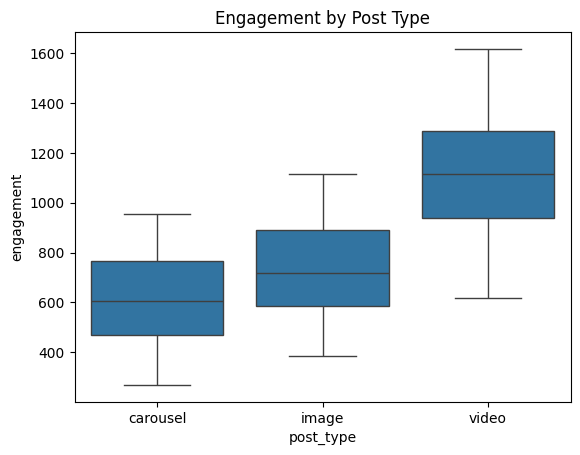

In [17]:
sns.boxplot(x="post_type", y="engagement", data=df)
plt.title("Engagement by Post Type")
plt.show()

In [18]:
df_model = pd.get_dummies(df[["post_type", "post_time", "followers"]], drop_first=True)

X = df_model
y = df["high_engagement"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8274309723889556


In [21]:
# Predict probabilities (for ROC)
y_prob = model.predict_proba(X_test)[:,1]

# Predict class labels (for confusion matrix)
y_pred = model.predict(X_test)

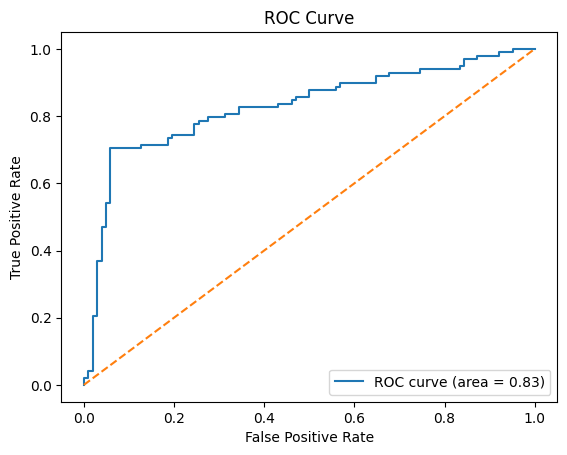

In [22]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

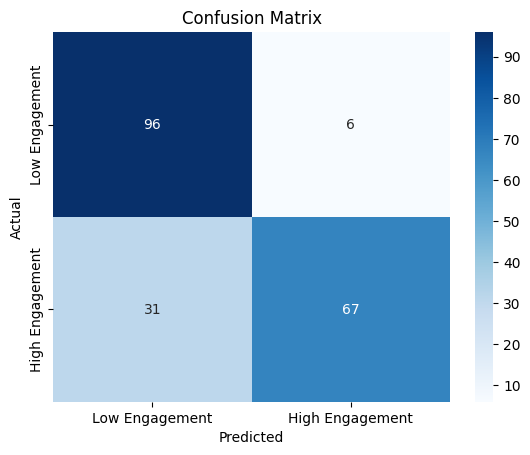

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

labels = ["Low Engagement", "High Engagement"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Note:** Model correctly identifies high-performing posts but occasionally misclassifies low-performing ones as high → acceptable trade-off for growth use case

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["segment"] = kmeans.fit_predict(df[["engagement"]])

In [25]:
video = df[df["post_type"] == "video"]["engagement"]
image = df[df["post_type"] == "image"]["engagement"]

t_stat, p_val = ttest_ind(video, image)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: 25.602942600217187
P-value: 1.0292255506020251e-101


In [26]:
print("Average Engagement:", df["engagement"].mean())
print("High Engagement Rate:", df["high_engagement"].mean())

Average Engagement: 818.379
High Engagement Rate: 0.5


**Let's now support the decision making by using Hypothesis testing:**

Null Hypothesis (H₀)

There is *no difference* in engagement between post types

Alternative Hypothesis (H₁)

There is *a difference* in engagement between post types

In [27]:
from scipy.stats import f_oneway

carousel = df[df["post_type"] == "carousel"]["engagement"]
image = df[df["post_type"] == "image"]["engagement"]
video = df[df["post_type"] == "video"]["engagement"]

f_stat, p_value = f_oneway(carousel, image, video)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 630.452879498684
P-value: 1.0646074338024304e-177


In [28]:
if p_value < 0.05:
    print("Reject null hypothesis: Post type impacts engagement")
else:
    print("Fail to reject null: No strong evidence that post type impacts engagement")

Reject null hypothesis: Post type impacts engagement


Let's now assess this finding with relevant visualizations:

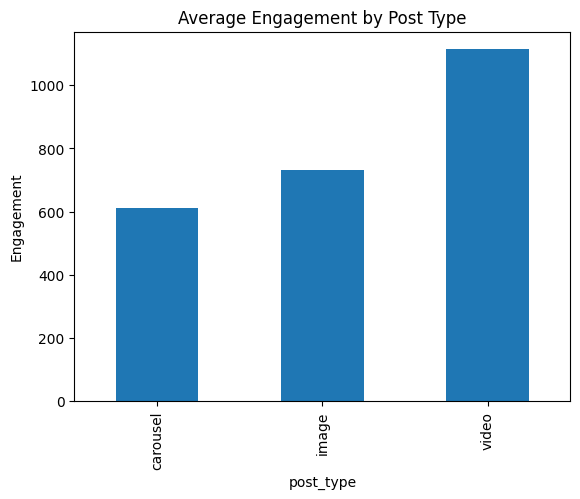

In [29]:
df.groupby("post_type")["engagement"].mean().plot(kind="bar")
plt.title("Average Engagement by Post Type")
plt.ylabel("Engagement")
plt.show()

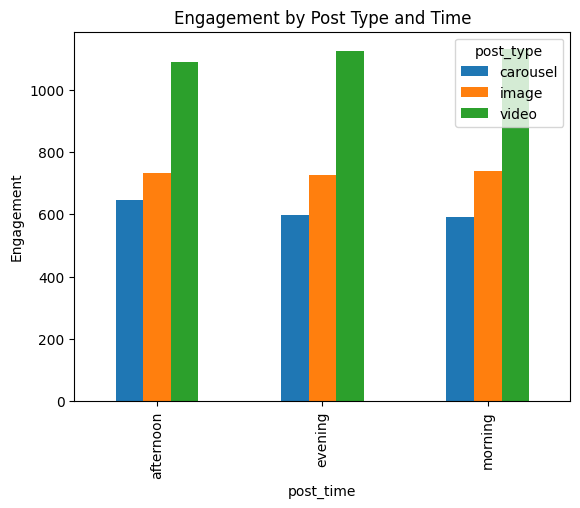

In [30]:
pivot = df.pivot_table(values="engagement", index="post_time", columns="post_type", aggfunc="mean")

pivot.plot(kind="bar")
plt.title("Engagement by Post Type and Time")
plt.ylabel("Engagement")
plt.show()

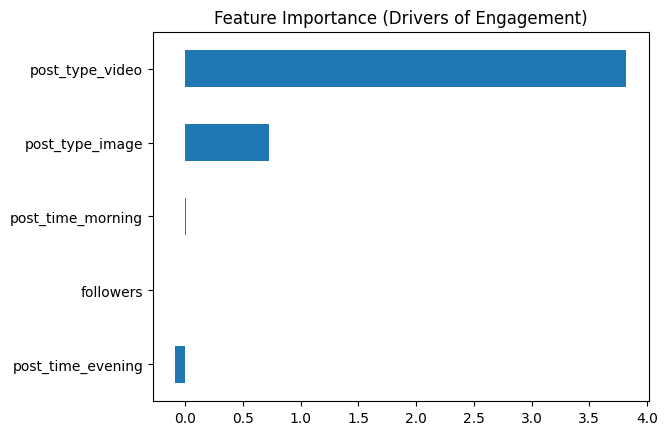

In [31]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Drivers of Engagement)")
plt.show()

In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["segment"] = kmeans.fit_predict(df[["engagement"]])

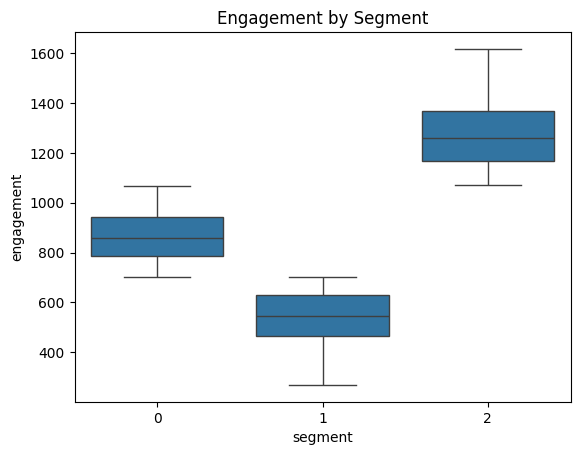

In [37]:
sns.boxplot(x="segment", y="engagement", data=df)
plt.title("Engagement by Segment")
plt.show()

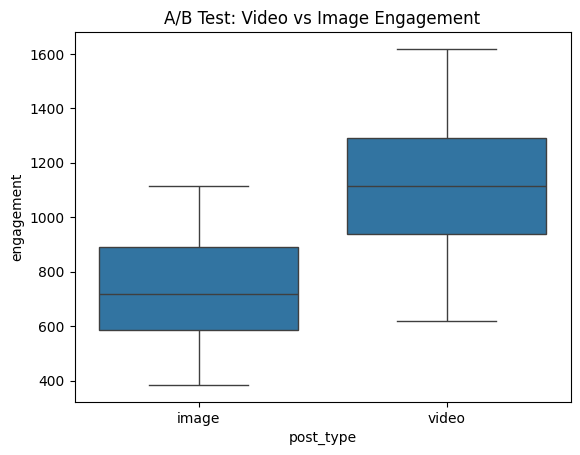

In [34]:
sns.boxplot(x="post_type", y="engagement", data=df[df["post_type"].isin(["video", "image"])])
plt.title("A/B Test: Video vs Image Engagement")
plt.show()

> Ofcourse this data is heavily skewed towards the video type and all the charts corraboarte with the hypothesis test findings. However, this project is basically a simulation to understand how we can use this to come to a decision making.

### **Key Insights:**

- We collect relevant data and do basic sanity check and clean up so that the data is usable.
- We find initial evidence that tells us that video posts do better however we do not yet have the statistical evidence to prove it.
- We split the data into train and test, then train the model and find the ROC depicting the engagement.
- Even though we see a lot of visual cues, we run an ANNOVA test to find out the significant statistical evidence to reject the null hypothesis and we are able to do it.
- This provides us a core insight that using video posts (for this simiulated data) should be a preferred choice for the brand to increase the engagement.